In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

读取AVI检测器检测数据，用MFST算法排序，构建匹配流量矩阵、匹配行程时间矩阵、断面流量矩阵

In [4]:
# 读取avi与边对应关系
file_path = 'net_data/output_E1.xml'
# 提取数据并存储在字典列表中
data = []
# 使用 iterparse 逐步解析 XML 文件
context = ET.iterparse(file_path, events=("start", "end"))
# 遍历解析的元素
for event, elem in context:
    # 只处理 "instantOut" 标签的结束事件
    if event == "end" and elem.tag == "instantOut":
        if elem.get('state') == 'enter':  # 只取 state='enter' 的数据
            entry = {
                'id': elem.get('id'),
                'time': float(elem.get('time')),
                'vehID': elem.get('vehID')
            }
            data.append(entry)
        
        # 清理已处理的元素，以减少内存使用
        elem.clear()
     
avidata = pd.DataFrame(data)
# 取离开时间 avidata[avidata['state']=='enter']
avidata['id'] = avidata['id'].astype(int)
avidata['time'] = avidata['time'].astype(float)
avidata

ParseError: unclosed token: line 3, column 0 (<string>)

20250506 sumo_avi中的csv文件read一下就是avidata，跑通后面的即可

In [22]:
# 读取E1_info.xml
tree = ET.parse('net_data/E1_info.xml')
root = tree.getroot()
data = []
for E1 in root.findall('instantInductionLoop'):
    entry = {
        'id': E1.get('id'),
        'link': int(float(E1.get('link'))),
    }
    data.append(entry)
avi_link_map = pd.DataFrame(data)['link']
# 确定avi所在边
avidata['link'] = avidata['id'].map(avi_link_map)
# 选取通车辆最大的部分AVI
avidata = avidata[avidata['link'].isin(avidata['link'].value_counts().head(200).index)]
avidata['k'] = (avidata['time'] // 3600).astype(int)
avidata['link_reset'] = pd.factorize(avidata['link'])[0]
AVINUM = len(avidata['link'].unique())
avidata

C:\Users\dell\AppData\Local\Temp\ipykernel_19032\2536243137.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avidata['k'] = (avidata['time'] // 3600).astype(int)
C:\Users\dell\AppData\Local\Temp\ipykernel_19032\2536243137.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avidata['link_reset'] = pd.factorize(avidata['link'])[0]


,id,time,vehID,link,k,link_reset
0,709,0.50,95.0,32058503487,0,0
1,1212,5.90,206.0,32058500743,0,1
3,1870,8.41,0.0,32058502499,0,2
4,1211,8.30,212.0,32058500743,0,1
5,709,9.03,157.0,32058503487,0,0
...,...,...,...,...,...,...
3471704,740,864993.32,99047.4,32058500208,240,38
3471705,465,864993.71,99004.67,32058505636,240,187
3471706,807,864993.72,99005.54,32058501227,240,34
3471707,291,864994.48,99003.87,32058500145,240,101


In [25]:
# 根据权重对边进行降序排列
def sort_edges_by_weight(Gd):
    sorted_edges = sorted(Gd.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    return sorted_edges

# 基于Kruskal改进的最大流量生成树算法(MFST)
def MFST(Gd):
    # 初始化并查集，用于环检测
    parent = {node: node for node in G.nodes}

    def find(node):
        # 查找节点的根
        if parent[node] != node:
            parent[node] = find(parent[node])
        return parent[node]

    def union(node1, node2):
        # 合并两个节点的集合
        root1, root2 = find(node1), find(node2)
        if root1 != root2:
            parent[root2] = root1
            return True
        return False

    # 初始化
    # w = np.sum([attr['weight'] for _, _, attr in Gd.edges(data=True)])
    T = nx.Graph()
    T.add_nodes_from(range(AVINUM))
    L_star = []
    # 对边按权重降序排列
    sorted_edges = sort_edges_by_weight(Gd)

    # 遍历每条边
    for u, v, attr in sorted_edges:
        # 判断是否满足条件
        if T.degree(u)<2 and T.degree(v)<2 and union(u, v):
            T.add_edge(u,v,weight=attr['weight'])
            # 添加边到最大流量生成树
            L_star.append((u, v))
            # w -= attr['weight']
    return L_star,T

# 匹配流量计算
import itertools
weights = np.zeros([AVINUM, AVINUM]) #匹配流量
for vehID, group in avidata.groupby('vehID'):
    avi_seq = list(group['link_reset'])
    combinations = list(itertools.combinations(avi_seq, 2))
    for comb in combinations:
        weights[comb[0],comb[1]] += 1

# 创建超图
G = nx.Graph()
G.add_nodes_from(range(AVINUM))
for i in range(AVINUM):
    for j in range(AVINUM):
        if i < j:
            G.add_edge(i, j, weight = weights[i,j] + weights[j,i])
L_star,T_star = MFST(G)
# AVI重排序后的序列
aviseq = list(nx.dfs_preorder_nodes(T_star))

In [26]:
def get_match_flow_time(avidata, aviseq=aviseq,AVINUM=AVINUM):  #获取输入张量
    weights = np.zeros([AVINUM, AVINUM]) #匹配流量
    times = np.zeros([AVINUM, AVINUM])   #匹配行程时间
    for vehID, group in avidata.groupby('vehID'):
        avi_seq = list(group['link_reset'])
        combinations = list(itertools.combinations(avi_seq, 2))
        for comb in combinations:
            weights[comb[0],comb[1]] += 1
            times[comb[0],comb[1]] += group.loc[group['link_reset']==comb[1],'time'].values[0] - group.loc[group['link_reset']==comb[0],'time'].values[0]
    # 创建掩码矩阵，标记 weights 中非零的元素位置
    mask = weights != 0
    # 用掩码矩阵进行逐元素相除，并忽略 weights 中为零的位置
    times[mask] = times[mask] / weights[mask]  # 仅对非零位置执行除法

    # aviseq排列weights 得到匹配流量矩阵、匹配时间矩阵
    match_flows = weights[np.ix_(aviseq, aviseq)]
    # 匹配时间矩阵
    match_times = times[np.ix_(aviseq, aviseq)]
    # 断面流量矩阵
    id_counts = avidata['id'].value_counts()
    sorted_counts = [id_counts.get(id_val, 0) for id_val in aviseq]   # 根据 aviseq 的顺序对计数进行排序
    section_flow = np.tile(np.array(sorted_counts).reshape(AVINUM, 1), (1, AVINUM))  # 将计数值转换为矩阵，每列内容相同
    return match_flows, match_times, section_flow

In [27]:
# 每2小时AVI数据分组
window_size = 2
# 初始化结果存储
grouped_data = []
# 获取所有唯一的 k 值
unique_k_values = avidata['k'].unique()
# 滑动窗口合并分组
for start_k in range(unique_k_values.min(), unique_k_values.max() - window_size + 2):
    # 选择符合条件的行
    selected_rows = avidata[(avidata['k'] >= start_k) & (avidata['k'] < start_k + window_size)]
    grouped_data.append(selected_rows)

In [28]:
# AVI观测量加载
tensors_perslot = []
for avidata2hour in grouped_data:
    match_flows, match_times, section_flow = get_match_flow_time(avidata2hour)
    tensor_perslot = np.stack((match_flows, match_times, section_flow), axis=-1)
    tensors_perslot.append(tensor_perslot)
    print(len(tensors_perslot),'AVI观测量加载完成')

1 AVI观测量加载完成
2 AVI观测量加载完成
3 AVI观测量加载完成
4 AVI观测量加载完成
5 AVI观测量加载完成
6 AVI观测量加载完成
7 AVI观测量加载完成
8 AVI观测量加载完成
9 AVI观测量加载完成
10 AVI观测量加载完成
11 AVI观测量加载完成
12 AVI观测量加载完成
13 AVI观测量加载完成
14 AVI观测量加载完成
15 AVI观测量加载完成
16 AVI观测量加载完成
17 AVI观测量加载完成
18 AVI观测量加载完成
19 AVI观测量加载完成
20 AVI观测量加载完成
21 AVI观测量加载完成
22 AVI观测量加载完成
23 AVI观测量加载完成
24 AVI观测量加载完成
25 AVI观测量加载完成
26 AVI观测量加载完成
27 AVI观测量加载完成
28 AVI观测量加载完成
29 AVI观测量加载完成
30 AVI观测量加载完成
31 AVI观测量加载完成
32 AVI观测量加载完成
33 AVI观测量加载完成
34 AVI观测量加载完成
35 AVI观测量加载完成
36 AVI观测量加载完成
37 AVI观测量加载完成
38 AVI观测量加载完成
39 AVI观测量加载完成
40 AVI观测量加载完成
41 AVI观测量加载完成
42 AVI观测量加载完成
43 AVI观测量加载完成
44 AVI观测量加载完成
45 AVI观测量加载完成
46 AVI观测量加载完成
47 AVI观测量加载完成
48 AVI观测量加载完成
49 AVI观测量加载完成
50 AVI观测量加载完成
51 AVI观测量加载完成
52 AVI观测量加载完成
53 AVI观测量加载完成
54 AVI观测量加载完成
55 AVI观测量加载完成
56 AVI观测量加载完成
57 AVI观测量加载完成
58 AVI观测量加载完成
59 AVI观测量加载完成
60 AVI观测量加载完成
61 AVI观测量加载完成
62 AVI观测量加载完成
63 AVI观测量加载完成
64 AVI观测量加载完成
65 AVI观测量加载完成
66 AVI观测量加载完成
67 AVI观测量加载完成
68 AVI观测量加载完成
69 AVI观测量加载完成
70 AVI观测量加载完成
71 AVI观测量加载完成
72 AVI观测量加载完成
7

In [29]:
# 每8小时一个样本
samples = []
for start in range(len(tensors_perslot)-7):
    sample = np.stack(tensors_perslot[start:start+8],axis=-1)
    samples.append(sample)
samples = np.stack(samples,axis=-1)
samples.shape

(200, 200, 3, 8, 233)

In [ ]:
# 标签数据构建
# flow1 = pd.read_pickle('flow1.pkl')
flow_data = []
for event, elem in ET.iterparse('net_data/flow1_10days.xml', events=("start",)):
    if elem.tag == "flow":  # 只处理 <flow> 标签
        flow_id = elem.get("id")         # 获取 id 属性
        flow_number = elem.get("number") # 获取 number 属性
        flow_via = elem.get('via')
        flow_begin = elem.get("begin")
        if flow_id and flow_number:
            flow_data.append({'fid':flow_id, 'number':int(flow_number), 'rs_reset':str(flow_via),'beginhour':int(flow_begin)/3600})  # 转换为整数并存储
        elem.clear()  # 清理元素以释放内存
flow_data = pd.DataFrame(flow_data)
flow_data['rs_r'], uniques = pd.factorize(flow_data['rs_reset'])

# 只选流量最大的路径256条
rs = flow_data.groupby('rs_r').sum().sort_values('number',ascending=False).head(256)['number'].index
labels = []
for start in range(233):
    fs = flow_data[(flow_data['beginhour']>=start) & (flow_data['beginhour']<start+8)].groupby('rs_r')['number'].sum()
    rs_counts = fs.reindex(rs, fill_value=0)
    labels.append(rs_counts)
labels = np.stack(labels,axis=-1)
labels.shape

(256, 233)

In [41]:
flow_data.groupby('rs_r').sum().sort_values('number',ascending=False).head(256)['number'].index

Index([  0,   2,   1,   3,   5,   4,   6,  17,  15,   8,
       ...
       621, 575, 125, 172, 386, 383, 319, 647, 853, 183],
      dtype='int64', name='rs_r', length=256)

Text(0, 0.5, 'Input Flow')

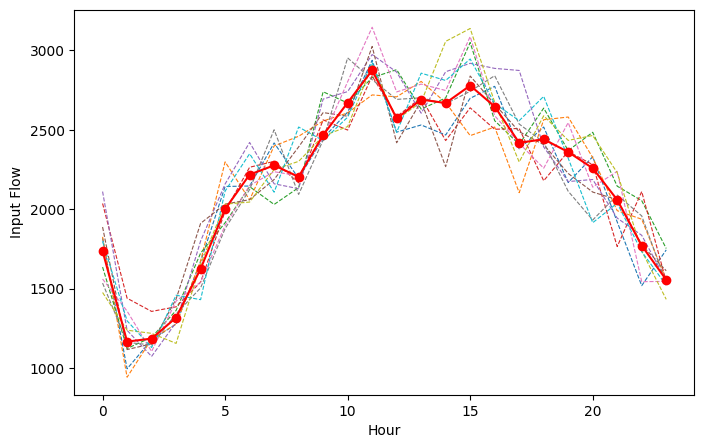

In [ ]:

flow1['k'] = flow1['begin']/3600
baseflow = flow1.groupby('k')['count'].sum()
plt.figure(figsize=(8, 5))
# 遍历分组并绘制到同一张图中
for group_values in genflows:
    plt.plot(group_values.index, group_values.values, linestyle='--',lw=0.8)
plt.plot(baseflow.index, baseflow.values, marker = 'o',c='r')
plt.xlabel("Hour")
plt.ylabel("Input Flow")

(439, 439, 3, 8, 233)

In [46]:
np.save('samples.npy', samples.astype(np.float32))

In [47]:
np.save('labels.npy', labels.astype(np.float32))

In [6]:
samples = np.load('../taicangNet/samples.npy')
samples.shape

(200, 200, 3, 8, 233)

In [14]:
sample = samples[:,:,:,:,0].sum(axis=3)

In [7]:
labels = np.load('../taicangNet/labels.npy')
labels.shape

(256, 233)

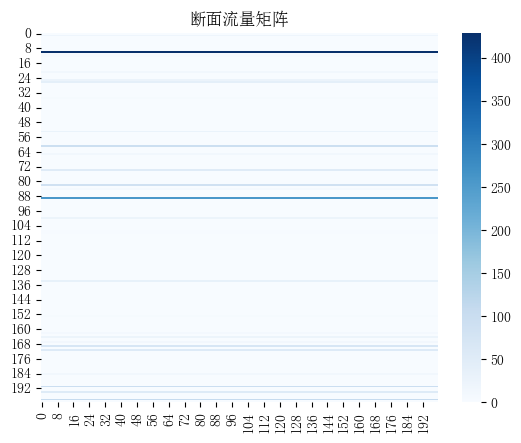

In [ ]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimSun']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

sns.heatmap(samples[:,:,2,0,11], cmap='Blues', annot=False, cbar=True) #改第三个值选择数据
plt.title('断面流量矩阵')
plt.show()